# SMS SPAM DEEP LEARNING
Etudiant : Amaury TISSOT

Classe : [DIS] MIA 26.2

## Dépendances

In [141]:
# Installation des dépendances du projet listées dans requirements.txt
!pip install -r ../requirements.txt

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Choix du dataset
Etant un véritable novice en matière de deeplearning, j'ai choisi le dataset suivant : [SMS Spam Collection — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) qui me semble approprié pour découvrir le concept de RNN.

## Importation du dataset

In [143]:
import io
import os
import zipfile
import urllib.request

DATA_DIR = "../data"
CSV_PATH = os.path.join(DATA_DIR, "sms_spam.csv")
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Téléchargement + extraction au premier lancement, puis lecture du cache local ensuite
if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    raw = urllib.request.urlopen(URL, timeout=60).read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])
    df.to_csv(CSV_PATH, index=False)
else:
    df = pd.read_csv(CSV_PATH)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploration des données (EDA)

### 1. Aperçu général

In [144]:
print("Dimensions (lignes, colonnes) :", df.shape)
df.info()

Dimensions (lignes, colonnes) : (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### 2. Valeurs manquantes et doublons

In [145]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nNombre de lignes en double :", df.duplicated().sum())

Valeurs manquantes par colonne :
label      0
message    0
dtype: int64

Nombre de lignes en double : 403


On supprime les doublons pour ne garder qu'un exemplaire de chaque message. `reset_index(drop=True)` renumérote les lignes proprement après suppression.

In [146]:
df = df.drop_duplicates().reset_index(drop=True)
print("Nouvelles dimensions du dataframe après suppression des doublons :", df.shape)

Nouvelles dimensions du dataframe après suppression des doublons : (5169, 2)


### 3. Répartition des classes (équilibre)

On regarde combien de "ham" ( messages légitimes) et de "spam" le data set contient.

- `value_counts()` compte les occurrences.
- `value_counts(normalize=True)` donne les proportions (en %).

In [147]:
print("Effectifs :")
print(df["label"].value_counts())
print("\nProportions en %:")
print((df["label"].value_counts(normalize=True) * 100).round(1))

Effectifs :
label
ham     4516
spam     653
Name: count, dtype: int64

Proportions en %:
label
ham     87.4
spam    12.6
Name: proportion, dtype: float64


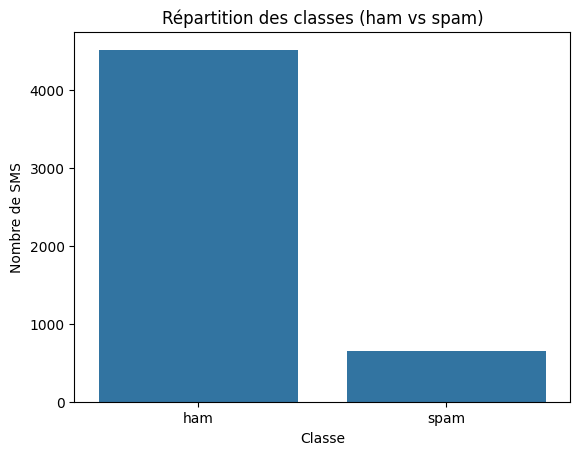

In [148]:
sns.countplot(data=df, x="label")
plt.title("Répartition des classes (ham vs spam)")
plt.xlabel("Classe")
plt.ylabel("Nombre de SMS")
plt.show()

On voit que les "ham" sont majoritaires (~87 %) face aux "spam" (~13 %) : le dataset est donc déséquilibré.

### 4. Longueur des messages

On vient comparer la longueur des messages "hame" et "spam".

In [149]:
df["length"] = df["message"].str.len()
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


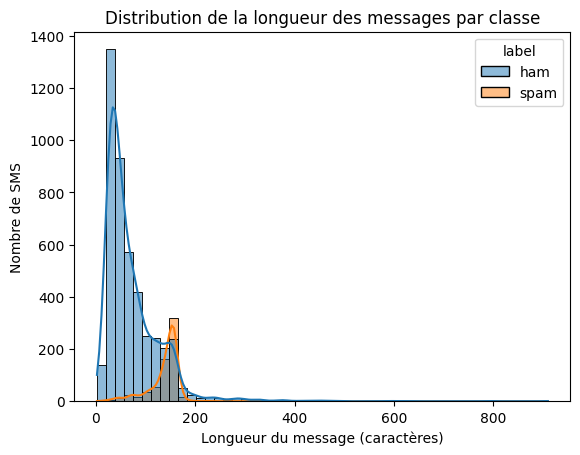

In [150]:
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribution de la longueur des messages par classe")
plt.xlabel("Longueur du message (caractères)")
plt.ylabel("Nombre de SMS")
plt.show()

On constate que les ham sont plus courts en moyenne que les spam.
La longueur des messages semble donc être un possible signal discriminant.

### 5. Extrait des données



In [151]:
print("Exemples de messages légitimes (HAM) :")
for msg in df[df["label"] == "ham"]["message"].head(3):
    print("-", msg)

print("\nExemples de messages de SPAM ===")
for msg in df[df["label"] == "spam"]["message"].head(3):
    print("-", msg)

Exemples de messages légitimes (HAM) :
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
- Ok lar... Joking wif u oni...
- U dun say so early hor... U c already then say...

Exemples de messages de SPAM ===
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
- WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


## Nettoyage des données

En explorant les données, nous avons constaté la présence des textes / caractères spéciaux : URL, symboles, etc.

La fonction `clean_text` ci-dessous :
- garantit une chaîne de caractères (robustesse face aux types inattendus / `NaN`) ;
- normalise l'Unicode (`NFKC`) pour unifier les variantes équivalentes d'un même caractère ;
- retire les caractères de contrôle invisibles ;
- uniformise les espaces (tabulations, retours à la ligne, espaces multiples → un seul espace) ;
- supprime les espaces en début et fin.

On garde le texte original dans `message` et on écrit le résultat dans une nouvelle colonne `message_clean`, pour pouvoir comparer.

In [152]:
import re
import unicodedata

# On normalise d'abord les étiquettes (espaces parasites, casse) par sécurité
df["label"] = df["label"].str.strip().str.lower()
print("Étiquettes uniques après normalisation :", df["label"].unique())

def clean_text(text):
    """Nettoyage robuste d'un message SMS.

    On normalise la *structure* du texte (encodage, espaces, caractères de
    contrôle) SANS détruire les signaux utiles au classifieur (URLs, numéros,
    symboles monétaires £/$, MAJUSCULES...), souvent de bons indices de spam.
    """
    # 1. Garantir une chaîne (robustesse face aux NaN / types inattendus)
    if not isinstance(text, str):
        return ""
    # 2. Normalisation Unicode (NFKC) : unifie les variantes équivalentes d'un caractère
    text = unicodedata.normalize("NFKC", text)
    # 3. Suppression des caractères de contrôle invisibles (on garde l'espace)
    text = "".join(ch for ch in text if ch == " " or unicodedata.category(ch)[0] != "C")
    # 4. Uniformisation des espaces (tabs, retours ligne, espaces multiples -> 1 espace)
    text = re.sub(r"\s+", " ", text)
    # 5. Suppression des espaces en début / fin
    return text.strip()

# On conserve l'original dans "message" et on écrit le résultat dans "message_clean"
df["message_clean"] = df["message"].apply(clean_text)

df[["message", "message_clean"]].head(3)

Étiquettes uniques après normalisation : ['ham' 'spam']


,message,message_clean
0,"Go until jurong point, crazy.. Available only ...","Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...


On effectue deux contrôles après le nettoyage :
- certains messages peuvent devenir vides (s'ils ne contenaient que des caractères invisibles) : on les retire ;
- le nettoyage peut faire réapparaître des doublons (deux messages qui ne différaient que par des espaces ou des caractères de structure) → on déduplique à nouveau, cette fois sur le couple `(label, message_clean)`.

In [153]:
# Messages devenus vides après nettoyage (ne contenaient que des caractères invisibles)
n_vides = (df["message_clean"].str.len() == 0).sum()
print("Messages vides après nettoyage :", n_vides)

avant = len(df)
df = df[df["message_clean"].str.len() > 0]                         
# Le nettoyage peut faire réapparaître des doublons (messages identiques à des espaces près)
df = df.drop_duplicates(subset=["label", "message_clean"]).reset_index(drop=True)

print(f"Lignes retirées (vides + nouveaux doublons) : {avant - len(df)}")
print("Dimensions après nettoyage des données :", df.shape)

Messages vides après nettoyage : 0
Lignes retirées (vides + nouveaux doublons) : 11
Dimensions après nettoyage des données : (5158, 4)


## Détection des anomalies

Ici, on cherche les anomalies susceptibles de fausser l'apprentissage, en distinguant deux familles :
- les anomalies à corriger : le bruit dans les données (étiquettes contradictoires) ;
- les anomalies à conserver : les valeurs extrêmes qui sont en réalité du signal (un spam très long ou bourré de chiffres n'est pas une erreur, c'est un spam).

### 1. Étiquettes contradictoires

Un même texte annoté à la fois ham et spam est une contradiction d'annotation : le modèle recevrait des signaux opposés pour une entrée identique.

In [154]:
# Un même texte annoté à la fois "ham" ET "spam" envoie des signaux opposés au modèle
conflits = (
    df.groupby("message_clean")["label"]
      .nunique()
      .loc[lambda s: s > 1]
)
print("Nombre de messages aux étiquettes contradictoires :", len(conflits))
if len(conflits):
    display(
        df[df["message_clean"].isin(conflits.index)]
        .sort_values("message_clean")[["label", "message_clean"]]
        .head(10)
    )

Nombre de messages aux étiquettes contradictoires : 0


### 2. Longueurs aberrantes

On repère les longueurs extrèmes avec un écart interquartile.  
On considére comme aberrante toute valeur hors de l'intervalle [Q1 − 1,5·IQR ; Q3 + 1,5·IQR]. On calcule les bornes par classe.
En effet, un message long est normal pour un spam mais inhabituel pour un ham.

 ham : 138 longueurs aberrantes (hors [0 ; 176] caractères)
spam :  64 longueurs aberrantes (hors [92 ; 196] caractères)


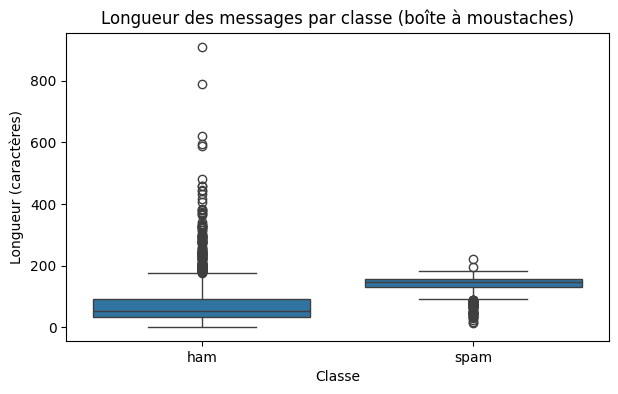

In [155]:
df["length"] = df["message_clean"].str.len()

def bornes_iqr(serie, k=1.5):
    """Bornes basse et haute selon la règle de l'écart interquartile."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Bornes calculées PAR CLASSE (un spam long n'est pas aberrant comme un ham long)
for cls in df["label"].unique():
    sub = df.loc[df["label"] == cls, "length"]
    bas, haut = bornes_iqr(sub)
    aberrants = sub[(sub < bas) | (sub > haut)]
    print(f"{cls:>4} : {len(aberrants):>3} longueurs aberrantes "
          f"(hors [{max(0, bas):.0f} ; {haut:.0f}] caractères)")

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="length")
plt.title("Longueur des messages par classe (boîte à moustaches)")
plt.xlabel("Classe")
plt.ylabel("Longueur (caractères)")
plt.show()

### 3. Composition des caractères

Le spam se distingue souvent par sa composition : beaucoup de chiffres (numéros, prix, codes), de majuscules (« WINNER!! ») ou de caractères non-ASCII ( ex: $, £, etc.).  
On quantifie ces proportions pour vérifier qu'elles séparent bien les deux classes.

In [156]:
def ratio(pattern, text):
    """Proportion de caractères correspondant au motif dans le texte."""
    if not text:
        return 0.0
    return len(re.findall(pattern, text)) / len(text)

df["ratio_chiffres"]   = df["message_clean"].apply(lambda t: ratio(r"\d", t))
df["ratio_majuscules"] = df["message_clean"].apply(lambda t: ratio(r"[A-Z]", t))
df["ratio_non_ascii"]  = df["message_clean"].apply(lambda t: ratio(r"[^\x00-\x7F]", t))

print("Composition moyenne des caractères par classe :")
display(df.groupby("label")[["ratio_chiffres", "ratio_majuscules", "ratio_non_ascii"]]
          .mean().round(3))

# Messages à composition extrême : plus de 50 % de chiffres ou de majuscules
suspects = df[(df["ratio_chiffres"] > 0.5) | (df["ratio_majuscules"] > 0.5)]
print(f"\nMessages à composition extrême (>50% chiffres ou majuscules) : {len(suspects)}")
display(suspects[["label", "message_clean", "ratio_chiffres", "ratio_majuscules"]].head(5))

Composition moyenne des caractères par classe :


,ratio_chiffres,ratio_majuscules,ratio_non_ascii
label,,,
ham,0.004,0.057,0.001
spam,0.115,0.110,0.003



Messages à composition extrême (>50% chiffres ou majuscules) : 112


,label,message_clean,ratio_chiffres,ratio_majuscules
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!,0.0,0.742857
43,ham,WHO ARE YOU SEEING?,0.0,0.789474
72,ham,HI BABE IM AT HOME NOW WANNA DO SOMETHING? XX,0.0,0.777778
128,ham,HEY GIRL. HOW R U? HOPE U R WELL ME AN DEL R B...,0.0,0.700935
238,ham,PLEASSSSSSSEEEEEE TEL ME V AVENT DONE SPORTSx,0.0,0.844444


Les seules anomalies réellement nettoyées sont les lignes vides et les doublons.  
En revanche, les longueurs extrêmes et les fortes proportions de chiffres/majuscules sont conservées : ce ne sont pas des erreurs mais des caractéristiques discriminantes du spam, que le modèle doit apprendre à reconnaître.

## Augmentation de données

Nous avons vu dans l'EDA que les données sont fortement déséquilibrées, nous alons procéder à une augementation des données.

Nous allons procédé à :
- un random swap : on échange deux mots au hasard ;
- une random deletion : on supprime chaque mot avec une faible probabilité.

Ces transformations conservent le sens global du message tout en produisant des exemples légèrement différents.

In [157]:
import random

random.seed(42)  # reproductibilité

def random_swap(words, n=1):
    """Échange n fois deux mots tirés au hasard."""
    words = words.copy()
    for _ in range(n):
        if len(words) < 2:
            break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def random_deletion(words, p=0.1):
    """Supprime chaque mot avec une probabilité p (en gardant au moins un mot)."""
    if len(words) <= 1:
        return words
    kept = [w for w in words if random.random() > p]
    return kept if kept else [random.choice(words)]

def augment(text, n=1, p=0.1):
    """Crée une variante d'un message : échange de mots puis suppression aléatoire."""
    words = text.split()
    words = random_swap(words, n=n)
    words = random_deletion(words, p=p)
    return " ".join(words)

# Démonstration sur un message de spam
exemple = df[df["label"] == "spam"]["message_clean"].iloc[0]
print("Original :", exemple)
print("Variante :", augment(exemple, n=2, p=0.1))

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Variante : question(std entry in to a comp win FA final tkts 21st May 2005. Text to 87121 2 receive entry Free apply 08452810075over18's


On découpe donc d'abord (avec `stratify` pour conserver les proportions), puis on augmente seulement la classe minoritaire (`spam`) du jeu d'entraînement pour le rééquilibrer.

In [158]:
from sklearn.model_selection import train_test_split

X = df["message_clean"]
y = df["label"]

# Découpage AVANT augmentation, avec stratification pour préserver les proportions ham/spam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Avant augmentation (train) :")
print(y_train.value_counts())

# Augmentation UNIQUEMENT du train et UNIQUEMENT de la classe minoritaire (spam)
train = pd.DataFrame({"message": X_train.values, "label": y_train.values})
spam_train = train[train["label"] == "spam"]["message"].reset_index(drop=True)
n_manquant = (y_train == "ham").sum() - (y_train == "spam").sum()

augmentes = [
    {"message": augment(spam_train.iloc[i % len(spam_train)], n=2, p=0.1), "label": "spam"}
    for i in range(n_manquant)
]
train_augmente = pd.concat([train, pd.DataFrame(augmentes)], ignore_index=True)

print(f"\n{n_manquant} spams synthétiques ajoutés.")
print("\nAprès augmentation (train rééquilibré) :")
print(train_augmente["label"].value_counts())
print("\nLe jeu de test reste intact :", len(X_test), "messages.")

Avant augmentation (train) :
label
ham     3612
spam     514
Name: count, dtype: int64

3098 spams synthétiques ajoutés.

Après augmentation (train rééquilibré) :
label
ham     3612
spam    3612
Name: count, dtype: int64

Le jeu de test reste intact : 1032 messages.


## Machine learning

### Pourquoi ElasticNet ?

La régularisation ajoute à la fonction de coût une pénalité sur la taille des coefficients, pour limiter le sur-apprentissage.  
Les trois formes classiques se retrouvent dans la régression via le paramètre `penalty` :

| Forme (régression) | Pénalité | `LogisticRegression` | Effet |
|---|---|---|---|
| Ridge | **L2** (somme des carrés) | `penalty='l2'` | rétrécit les coefficients, **les garde tous** |
| Lasso | **L1** (somme des valeurs absolues) | `penalty='l1'` | **annule** des coefficients → parcimonie / sélection |
| ElasticNet | **L1 + L2** | `penalty='elasticnet'` | combine sélection **et** stabilité |

Choix retenu : ElasticNet, parce qu'il colle au profil de nos données :
1. le TF-IDF est très haute dimension et creux (des milliers de termes, en majorité inutiles) → la part L1 fait une sélection de variables automatique et rend le modèle interprétable ;
2. les mots du spam sont corrélés (free / win / prize / claim co-apparaissent) : le Lasso pur en choisit un au hasard et devient instable → la part L2 stabilise ces groupes ;
3. ElasticNet réunit donc les avantages de Ridge et de Lasso — le meilleur compromis pour du texte.

### 1. Vectorisation TF-IDF

Un modèle ML ne traite pas du texte brut : il faut le transformer en vecteurs numériques. On utilise TF-IDF (Term Frequency – Inverse Document Frequency), qui pondère chaque terme par sa fréquence dans le message et sa rareté dans l'ensemble du corpus — les mots très communs (« the », « to ») pèsent peu, les mots discriminants pèsent davantage.

In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Données issues du découpage précédent.
# Train AUGMENTÉ et rééquilibré ; test intact (jamais augmenté) -> évaluation honnête.
X_train_txt = train_augmente["message"]
y_train_bl  = train_augmente["label"]
# X_test, y_test proviennent déjà du split stratifié réalisé plus haut.

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),   # unigrammes + bigrammes ("free entry", "txt rate"...)
    min_df=2,             # ignore les termes présents dans < 2 messages (bruit)
    sublinear_tf=True,    # 1 + log(tf) : atténue le poids des répétitions
)

# fit_transform sur le train, transform seul sur le test -> aucune fuite de vocabulaire
X_train_vec = vectorizer.fit_transform(X_train_txt)
X_test_vec  = vectorizer.transform(X_test)

print("Matrice train :", X_train_vec.shape)
print("Matrice test  :", X_test_vec.shape)
print(f"Vocabulaire   : {len(vectorizer.vocabulary_)} termes")

Matrice train : (7224, 18483)
Matrice test  : (1032, 18483)
Vocabulaire   : 18483 termes


### 2. Entraînement de la baseline et choix des métriques

On entraîne une régression logistique régularisée en ElasticNet sur le train (vectorisé et rééquilibré) et on l'évalue sur le test intact.

Choix des métriques. Le test reste déséquilibré (~87 % ham). L'accuracy y est trompeuse : un modèle qui prédit toujours « ham » obtiendrait déjà ~87 %. On privilégie donc :
- la précision (parmi les messages classés spam, combien le sont vraiment → éviter de bloquer un vrai message),
- le rappel (parmi les vrais spams, combien sont détectés),
- le F1, leur moyenne harmonique, et la matrice de confusion pour visualiser les erreurs.

Rapport de classification (jeu de test)
              precision    recall  f1-score   support

         ham      0.990     0.966     0.978       904
        spam      0.793     0.930     0.856       128

    accuracy                          0.961      1032
   macro avg      0.892     0.948     0.917      1032
weighted avg      0.965     0.961     0.963      1032



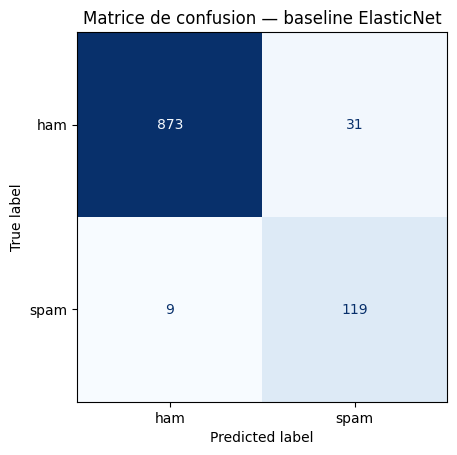

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

# Baseline : régression logistique régularisée ElasticNet (mélange L1 + L2)
#   - L1 -> parcimonie : met à 0 les mots non informatifs (sélection de variables)
#   - L2 -> stabilité  : gère les groupes de mots corrélés (free / win / prize ...)
# solver='saga' : le seul de sklearn qui supporte la pénalité 'elasticnet'.
baseline = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,      # 50 % L1 / 50 % L2
    C=1.0,             # inverse de la force de régularisation
    max_iter=2000,
    random_state=42,
)
baseline.fit(X_train_vec, y_train_bl)

y_pred = baseline.predict(X_test_vec)

print("Rapport de classification (jeu de test)")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues", colorbar=False)
plt.title("Matrice de confusion — baseline ElasticNet")
plt.show()

### 3. Démonstration de l'effet de la régularisation

On compare donc plusieurs réglages en faisant varier les deux leviers d'ElasticNet:
- **`l1_ratio`** : le dosage entre L1 et L2. `0.0` = **Ridge pur** (L2), `1.0` = **Lasso pur** (L1), entre les deux = **ElasticNet** ;
- **`C`** : l'inverse de la force de régularisation. Un `C` **petit** régularise **fort** (coefficients tirés vers 0).

In [161]:
# On illustre les DEUX leviers de la régularisation :
#   - l1_ratio : dosage L1 vs L2  (0 = Ridge pur, 1 = Lasso pur, entre les deux = ElasticNet)
#   - C        : force globale    (C petit = régularisation forte = davantage de coefs à 0)
resultats = []
for C in [0.1, 1.0, 10.0]:
    for l1_ratio in [0.0, 0.5, 1.0]:
        m = LogisticRegression(penalty="elasticnet", solver="saga",
                               l1_ratio=l1_ratio, C=C, max_iter=2000, random_state=42)
        m.fit(X_train_vec, y_train_bl)
        coefs = m.coef_.ravel()
        nnz = int((coefs != 0).sum())
        f1 = f1_score(y_test, m.predict(X_test_vec), pos_label="spam")
        resultats.append({
            "type": {0.0: "Ridge (L2)", 1.0: "Lasso (L1)"}.get(l1_ratio, "ElasticNet"),
            "C": C,
            "l1_ratio": l1_ratio,
            "coefs_non_nuls": nnz,
            "part_nulle_%": round(100 * (1 - nnz / len(coefs)), 1),
            "F1_spam": round(f1, 3),
        })

tab = pd.DataFrame(resultats)
display(tab.sort_values(["C", "l1_ratio"]).reset_index(drop=True))

c:\Users\G713\repos\IPSSI\deep_learning\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,type,C,l1_ratio,coefs_non_nuls,part_nulle_%,F1_spam
0,Ridge (L2),0.1,0.0,18483,0.0,0.850
1,ElasticNet,0.1,0.5,154,99.2,0.760
2,Lasso (L1),0.1,1.0,28,99.8,0.710
3,Ridge (L2),1.0,0.0,18483,0.0,0.906
4,ElasticNet,1.0,0.5,1322,92.8,0.856
5,Lasso (L1),1.0,1.0,231,98.8,0.858
6,Ridge (L2),10.0,0.0,18483,0.0,0.919
7,ElasticNet,10.0,0.5,4434,76.0,0.921
8,Lasso (L1),10.0,1.0,590,96.8,0.904


Lecture du tableau :   
- plus la part L1 est forte, plus le modèle est parcimonieux (beaucoup de mots mis à zéro). Le Ridge pur (`l1_ratio=0`) garde au contraire tous les coefficients.
- Le F1 reste élevé même avec beaucoup de zéros : on peut donc supprimer une grande partie des features sans perdre en performance

### 4. Interprétation

Dans un modèle linéaire régularisé : chaque mot possède un coefficient. Les plus positifs tirent vers la classe positive (spam), les plus négatifs vers ham.

In [162]:
import numpy as np

# Coefficients de la baseline ElasticNet (l1_ratio=0.5, C=1).
# En binaire, coef_ correspond à la classe positive = classes_[1].
features = np.array(vectorizer.get_feature_names_out())
coefs = baseline.coef_.ravel()
ordre = np.argsort(coefs)

print("Classe positive (coef > 0) :", baseline.classes_[1])
print(f"Termes retenus (coef != 0) : {(coefs != 0).sum()} / {len(coefs)}")

print("\n--- 15 termes les plus prédictifs de SPAM ---")
for i in ordre[::-1][:15]:
    print(f"  {features[i]:<22} {coefs[i]:+.3f}")

print("\n--- 15 termes les plus prédictifs de HAM ---")
for i in ordre[:15]:
    print(f"  {features[i]:<22} {coefs[i]:+.3f}")

Classe positive (coef > 0) : spam
Termes retenus (coef != 0) : 1322 / 18483

--- 15 termes les plus prédictifs de SPAM ---
  call                   +10.660
  txt                    +7.991
  text                   +7.233
  free                   +6.107
  stop                   +5.536
  150p                   +5.480
  claim                  +5.460
  reply                  +5.293
  www                    +5.116
  uk                     +5.093
  mobile                 +5.088
  50                     +4.825
  to                     +4.747
  chat                   +4.712
  service                +4.708

--- 15 termes les plus prédictifs de HAM ---
  my                     -5.997
  me                     -5.120
  that                   -3.909
  ok                     -3.862
  but                    -3.465
  it                     -3.358
  da                     -3.274
  he                     -3.193
  how                    -3.139
  then                   -3.116
  gt                     -3.00

### Bilan de l'approche machine learning

L'utilisation d'ElasticNet atteint déjà de très bons scores, ce qui en fait une référence à battre pour le modèle de deep learning (RNN) à venir.

## Visualisation de synthèse

Pour clôturer l'approche ML, on récapitule visuellement deux choses :
- ce que le modèle a appris → les coefficients les plus discriminants ;
- à quel point il performe → les courbes ROC et précision-rappel.

Ces figures réutilisent les objets déjà entraînés plus haut (`baseline`, `vectorizer`) : aucune nouvelle étape de modélisation n'est introduite.

### 1. Termes les plus discriminants

Version graphique de l'interprétation précédente : on affiche côte à côte les 15 coefficients les plus négatifs (signaux de ham, en bleu) et les 15 plus positifs (signaux de **spam**, en rouge).

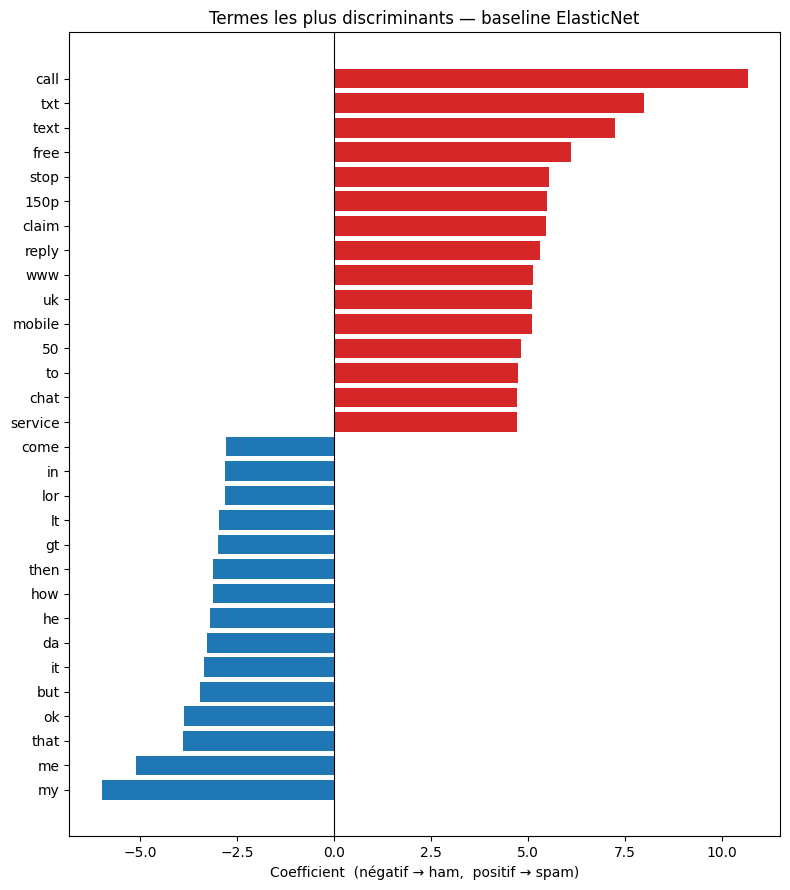

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# Coefficients de la baseline ElasticNet ; classe positive = spam
features = np.array(vectorizer.get_feature_names_out())
coefs    = baseline.coef_.ravel()
ordre    = np.argsort(coefs)

k = 15
# k coefficients les plus négatifs (ham) + k les plus positifs (spam), triés par valeur
idx = np.concatenate([ordre[:k], ordre[-k:]])
idx = idx[np.argsort(coefs[idx])]

noms     = features[idx]
valeurs  = coefs[idx]
couleurs = ["#d62728" if v > 0 else "#1f77b4" for v in valeurs]  # rouge = spam, bleu = ham

plt.figure(figsize=(8, 9))
plt.barh(range(len(idx)), valeurs, color=couleurs)
plt.yticks(range(len(idx)), noms)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient  (négatif → ham,  positif → spam)")
plt.title("Termes les plus discriminants — baseline ElasticNet")
plt.tight_layout()
plt.show()

### 2. Courbes ROC et précision-rappel

Pour la courbe précision-rappel : sa ligne de hasard correspond à la proportion de spam, et la précision moyenne (AP) résume la qualité du classement. L'AUC de la ROC mesure quant à elle la capacité du modèle à ranger un spam avant un ham.

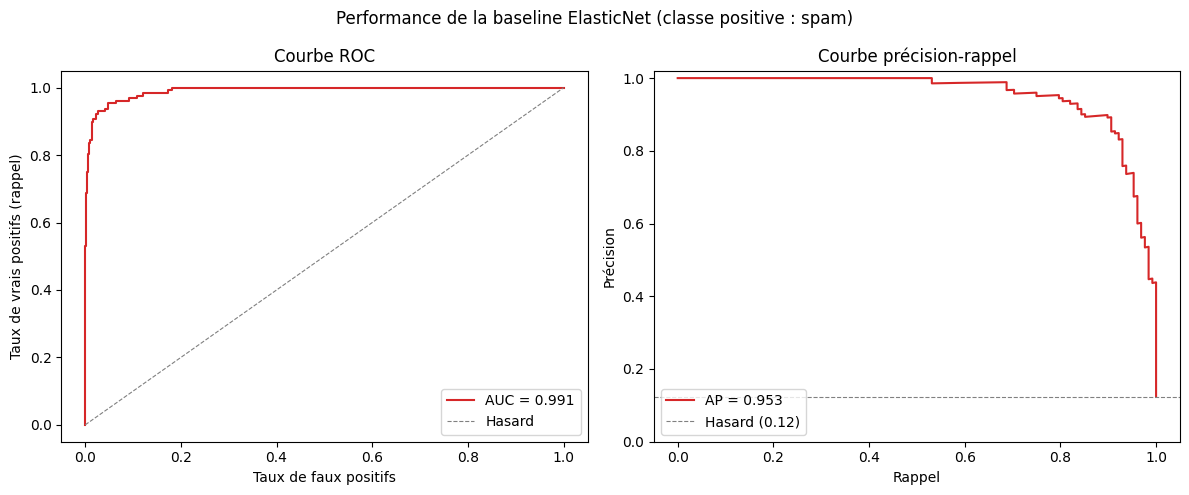

In [164]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score)

# Score de la classe positive (spam) pour chaque message du test
spam_idx   = list(baseline.classes_).index("spam")
y_score    = baseline.predict_proba(X_test_vec)[:, spam_idx]
y_true_bin = (y_test == "spam").astype(int)

fpr, tpr, _   = roc_curve(y_true_bin, y_score)
roc_auc       = auc(fpr, tpr)
prec, rec, _  = precision_recall_curve(y_true_bin, y_score)
ap            = average_precision_score(y_true_bin, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC ---
axes[0].plot(fpr, tpr, color="#d62728", label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=0.8, label="Hasard")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC")
axes[0].legend(loc="lower right")

# --- Précision-rappel ---
axes[1].plot(rec, prec, color="#d62728", label=f"AP = {ap:.3f}")
axes[1].axhline(y_true_bin.mean(), ls="--", color="grey", linewidth=0.8,
                label=f"Hasard ({y_true_bin.mean():.2f})")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe précision-rappel")
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower left")

plt.suptitle("Performance de la baseline ElasticNet (classe positive : spam)")
plt.tight_layout()
plt.show()

# Deep Learning

Après le machine learning, nous allons passer au deep learning.  
Avant de procéder à la mise en place du réseau de neurones, il nous faut choisir le type de réseau le plus adapté à nos données. L

Nos données sont des SMS, c'est-à-dire de courtes suites de mots où l'ordre a du sens. Le MLP n'est pas opportun car il ne tient pas compte de cet ordre.   Le CNN, quant à lui, ne voit que des morceaux courts.   
Le RNN, lui, traite le message en séquence et garde en mémoire le contexte des mots précédents.

Nous allons donc partir sur le RNN. 

## Recherche des hyperparamètres pertinents

Avant de procéder à l'entrainement du réseau nous avons procédés aux choix suivants :

### Le choix de l'optimiseur

Nous avons opté pour Adam optimiseur car il ajuste tout seul la vitesse d'apprentissage et reste stable sur la majorité des problèmes.

### Le problème du vanishing / exploding gradient

#### Les fonctions d'activation

Les fonctions d'activation décident de ce que chaque neurone transmet. Certaines peuvent aggraver le vanishing gradient.

Nous alons donc privilégier :
- ReLU pour les couches denses, car elle laisse passer le signal sans l'écraser
- une cellule de type LSTM pour la partie récurrente. Ces cellules protègeront le gradient sur de longues séquences.

#### La normalisation

Concernant la normalisation, nous utiliserons une Layer Normalization qui est bien plus stable que la Batch Normalization pour un RNN.

#### Le gradient clipping

Enfin, pour éviter l'exploding gradient, nous allons limiter la taille du gradient (gradient clipping) : dès qu'il dépasse un seuil, on le ramène à une valeur maximale.


### Mise en pratique

Nous avons fait le choix d'utiliser un modèle Keras avec TensorFlow.  
On va commencer  par transformer chaque message en une suite d'entiers (un identifiant par mot), puis uniformiser la longueur des messages. On réutilise le découpage train / test réalisé en amont.

In [165]:
# === Boite a outils RNN en PyTorch (reutilisee par les deux sections) ===
# TensorFlow ne supporte plus le GPU sur Windows natif ; on reecrit donc le RNN
# en PyTorch, qui exploite la RTX 3070 (cuDNN s'active tout seul sur LSTM en GPU).
import re, time, types
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device RNN :", device)
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

PAD, OOV = 0, 1  # index reserves : 0 = padding, 1 = mot inconnu (OOV)

def construire_vocab(textes, taille_max):
    """Vocabulaire appris sur le TRAIN : les (taille_max - 2) mots les plus frequents."""
    cpt = Counter()
    for t in textes:
        cpt.update(re.findall(r"\w+", str(t).lower()))
    return {mot: i + 2 for i, (mot, _) in enumerate(cpt.most_common(taille_max - 2))}

def encoder_sequences(textes, vocab, max_len):
    """Texte -> suite d'entiers (padding / troncature a max_len)."""
    seqs = []
    for t in textes:
        ids = [vocab.get(m, OOV) for m in re.findall(r"\w+", str(t).lower())][:max_len]
        ids += [PAD] * (max_len - len(ids))
        seqs.append(ids)
    return torch.tensor(seqs, dtype=torch.long)

class RNNSpam(nn.Module):
    """Embedding -> LSTM -> mean-pooling masque -> LayerNorm -> Dense(ReLU) -> Dropout -> sortie.

    Point cle : les SMS sont courts (~15 mots) mais completes a max_len par du padding.
    Prendre le dernier etat cache reviendrait a le lire APRES des dizaines de pas de
    padding, ce qui dilue le signal vers zero. On fait donc la MOYENNE des sorties du
    LSTM sur les vrais tokens uniquement (le masque ignore le padding). Sortie en logit."""
    def __init__(self, taille_vocab, dim_embedding=64, dim_lstm=64):
        super().__init__()
        self.embedding = nn.Embedding(taille_vocab, dim_embedding, padding_idx=PAD)
        self.lstm = nn.LSTM(dim_embedding, dim_lstm, batch_first=True)
        self.norm = nn.LayerNorm(dim_lstm)
        self.dense = nn.Linear(dim_lstm, 32)
        self.dropout = nn.Dropout(0.3)
        self.sortie = nn.Linear(32, 1)

    def forward(self, x):
        e = self.embedding(x)
        sorties, _ = self.lstm(e)                       # (B, T, H) : sortie a chaque pas
        masque = (x != PAD).unsqueeze(-1).float()       # (B, T, 1) : 1 sur les vrais tokens
        z = (sorties * masque).sum(1) / masque.sum(1).clamp(min=1)  # moyenne sur les vrais tokens
        z = self.norm(z)
        z = torch.relu(self.dense(z))
        z = self.dropout(z)
        return self.sortie(z).squeeze(1)                # logit

def entrainer_rnn(model, X, y, epochs, batch_size, val_split=0.1, lr=1e-3, seed=42):
    """Boucle d'entrainement : Adam + gradient clipping, suivi train / validation.
    Renvoie un objet 'historique' compatible Keras (.history[...]) pour les courbes."""
    torch.manual_seed(seed)
    model = model.to(device)
    y = torch.tensor(y, dtype=torch.float32)

    # Decoupage validation sur des indices MELANGES : sinon, si le train est ordonne
    # par classe (cas de l'UCI ou les spams augmentes sont ajoutes a la fin), la
    # validation se retrouverait mono-classe et la val_acc n'aurait aucun sens.
    perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(seed))
    n_val = int(len(X) * val_split)
    vi, ti = perm[:n_val], perm[n_val:]
    Xtr, ytr = X[ti], y[ti]
    Xvl, yvl = X[vi], y[vi]
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    perte_fn = nn.BCEWithLogitsLoss()
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

    for ep in range(epochs):
        model.train()
        pertes, bons, n = [], 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            perte = perte_fn(out, yb)
            perte.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # contre l'exploding gradient
            opt.step()
            pertes.append(perte.item())
            bons += ((out >= 0) == (yb >= 0.5)).sum().item(); n += len(yb)
        model.eval()
        with torch.no_grad():
            ov = model(Xvl.to(device)); yv = yvl.to(device)
            vl = perte_fn(ov, yv).item()
            va = ((ov >= 0) == (yv >= 0.5)).float().mean().item()
        hist["loss"].append(float(np.mean(pertes))); hist["accuracy"].append(bons / n)
        hist["val_loss"].append(vl); hist["val_accuracy"].append(va)
        print(f"Epoch {ep+1}/{epochs}  perte {hist['loss'][-1]:.4f}  "
              f"val_loss {vl:.4f}  val_acc {va:.3f}")
    return types.SimpleNamespace(history=hist)

def predire(model, X, batch_size=256):
    """Probabilites de spam (numpy) sur X."""
    model.eval()
    probas = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out = model(X[i:i + batch_size].to(device))
            probas.append(torch.sigmoid(out).cpu().numpy())
    return np.concatenate(probas)

Device RNN : cuda
GPU        : NVIDIA GeForce RTX 3070 Laptop GPU


In [166]:
# Le RNN lit des suites d'entiers : on convertit chaque mot en un identifiant.
num_mots = 10000   # on ne garde que les 10 000 mots les plus frequents
max_len  = 50      # toutes les sequences sont ramenees a 50 mots (padding / troncature)

# Vocabulaire appris sur le TRAIN uniquement -> aucune fuite vers le test
vocab = construire_vocab(X_train_txt.values, num_mots)
vocab_size = len(vocab) + 2  # + padding + OOV

X_train_seq = encoder_sequences(X_train_txt.values, vocab, max_len)
X_test_seq  = encoder_sequences(X_test.values, vocab, max_len)

# Etiquettes en 0 / 1 (spam = 1)
y_train_rnn = (y_train_bl == "spam").astype("int32").values
y_test_rnn  = (y_test == "spam").astype("int32").values

print("Forme train :", tuple(X_train_seq.shape), " | test :", tuple(X_test_seq.shape))
print("Taille du vocabulaire :", vocab_size)

Forme train : (7224, 50)  | test : (1032, 50)
Taille du vocabulaire : 7726


In [167]:
torch.manual_seed(42)  # reproductibilite

# Meme architecture que la version Keras (seul l'input_dim change avec le vocabulaire) :
# Embedding(64) -> LSTM(64) -> LayerNorm -> Dense(32, ReLU) -> Dropout(0.3) -> sortie
model = RNNSpam(taille_vocab=vocab_size)
print(model)
print(f"Nombre de parametres : {sum(p.numel() for p in model.parameters()):,}")

RNNSpam(
  (embedding): Embedding(7726, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dense): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sortie): Linear(in_features=32, out_features=1, bias=True)
)
Nombre de parametres : 529,985


## Entraînement du RNN

On entraîne maintenant le modèle sur le jeu d'entraînement (déjà rééquilibré par augmentation). On garde une petite partie en validation pour surveiller le sur-apprentissage, et on mesure le temps de calcul pour pouvoir le comparer ensuite à la baseline machine learning.

In [168]:
debut = time.time()
historique = entrainer_rnn(
    model, X_train_seq, y_train_rnn,
    epochs=5, batch_size=64, val_split=0.1,
)
temps_rnn = time.time() - debut
print(f"\nTemps d'entrainement du RNN : {temps_rnn:.1f} s")

Epoch 1/5  perte 0.3676  val_loss 0.1745  val_acc 0.932
Epoch 2/5  perte 0.1099  val_loss 0.0724  val_acc 0.971
Epoch 3/5  perte 0.0426  val_loss 0.0534  val_acc 0.981
Epoch 4/5  perte 0.0187  val_loss 0.0435  val_acc 0.983
Epoch 5/5  perte 0.0076  val_loss 0.0441  val_acc 0.986

Temps d'entrainement du RNN : 7.9 s


### Courbes d'apprentissage

On visualise l'évolution de la perte et de l'exactitude au fil des époques, sur le train et sur la validation. Si les deux courbes s'écartent fortement, c'est le signe d'un sur-apprentissage.

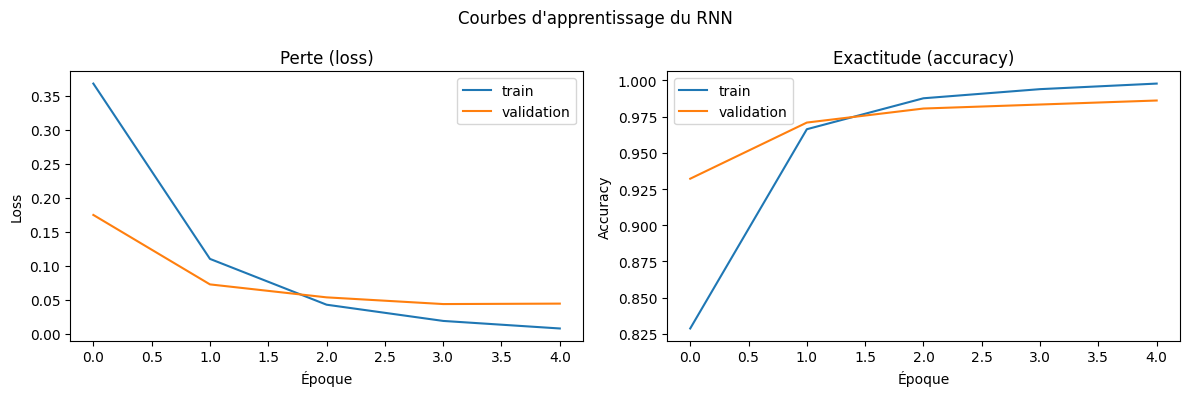

In [169]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historique.history["loss"], label="train")
axes[0].plot(historique.history["val_loss"], label="validation")
axes[0].set_title("Perte (loss)")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(historique.history["accuracy"], label="train")
axes[1].plot(historique.history["val_accuracy"], label="validation")
axes[1].set_title("Exactitude (accuracy)")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Courbes d'apprentissage du RNN")
plt.tight_layout()
plt.show()

## Évaluation et comparaison avec la baseline

On évalue le RNN sur le jeu de test (resté intact) avec les mêmes métriques que la baseline : précision, rappel et F1 sur la classe spam. On mesure aussi le temps d'entraînement de la baseline pour comparer les deux approches sur un pied d'égalité.

In [170]:
import time
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Prédictions du RNN sur le test ---
proba_rnn  = predire(model, X_test_seq)
y_pred_rnn = (proba_rnn >= 0.5).astype(int)
y_test_bin = (y_test == "spam").astype(int).values

# --- Re-mesure du temps d'entraînement de la baseline ML (comparaison équitable) ---
debut    = time.time()
baseline.fit(X_train_vec, y_train_bl)
temps_ml = time.time() - debut
y_pred_bl = (baseline.predict(X_test_vec) == "spam").astype(int)

# --- Tableau comparatif (métriques sur la classe spam) ---
comparaison = pd.DataFrame(
    {
        "Précision (spam)": [precision_score(y_test_bin, y_pred_bl),
                             precision_score(y_test_bin, y_pred_rnn)],
        "Rappel (spam)":    [recall_score(y_test_bin, y_pred_bl),
                             recall_score(y_test_bin, y_pred_rnn)],
        "F1 (spam)":        [f1_score(y_test_bin, y_pred_bl),
                             f1_score(y_test_bin, y_pred_rnn)],
        "Temps d'entraînement (s)": [temps_ml, temps_rnn],
    },
    index=["Baseline ElasticNet", "RNN (LSTM)"],
).round(3)

display(comparaison)

,Précision (spam),Rappel (spam),F1 (spam),Temps d'entraînement (s)
Baseline ElasticNet,0.793,0.930,0.856,0.723
RNN (LSTM),0.910,0.867,0.888,7.947


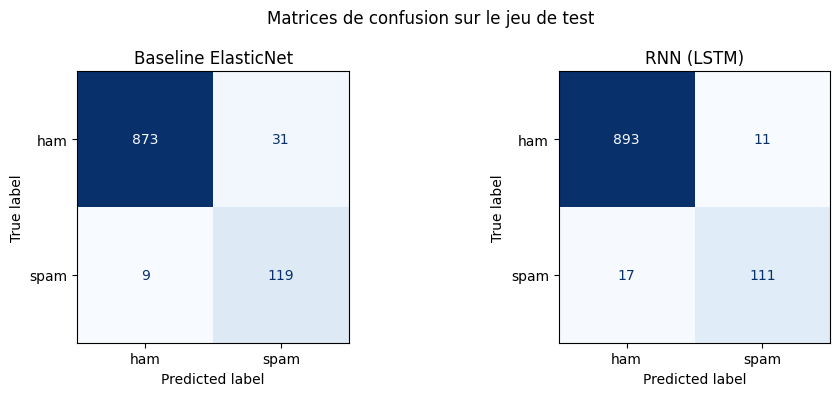

In [171]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_bin, y_pred_bl), display_labels=["ham", "spam"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Baseline ElasticNet")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_bin, y_pred_rnn), display_labels=["ham", "spam"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("RNN (LSTM)")

plt.suptitle("Matrices de confusion sur le jeu de test")
plt.tight_layout()
plt.show()

### Bilan de la comparaison

Les deux approches obtiennent de très bons scores sur la classe spam (voir le tableau ci-dessus). Sur ce jeu propre, c'est le RNN qui l'emporte : un F1 de 0.888 (précision 0.910, rappel 0.867) contre 0.856 pour la baseline ElasticNet. Le réseau récurrent, qui lit le message dans l'ordre, fait donc un peu mieux que le modèle linéaire — y compris sur un jeu de données aussi modeste, alors qu'on attend souvent l'inverse du deep learning.

Temps de calcul. C'est l'écart le plus visible, et il joue en faveur du machine learning. La baseline s'entraîne en moins d'une seconde (0.7 s), là où le RNN demande environ 8 secondes sur GPU — soit un ordre de grandeur de plus pour un gain de F1 modéré.

Limites du RNN sur ce jeu de données :
- il est plus difficile à interpréter : on ne lit pas un coefficient par mot comme dans le modèle linéaire ;
- il a davantage de réglages à fixer (architecture, longueur de séquence, hyperparamètres) ;
- son entraînement reste nettement plus coûteux, même si le GPU ramène ce coût à quelques secondes.

Limites de la baseline ML :
- elle raisonne surtout sur la présence de mots et tient mal compte de leur ordre ;
- le RNN, lui, lit le message dans l'ordre et garde le contexte : c'est son atout, qui devrait peser encore davantage sur des textes plus longs ou plus complexes.

Conclusion. Sur ce problème, le RNN est le meilleur en terme de précision. ElasticNet reste néanmoins une référence très solide : presque aussi performante, beaucoup plus rapide et directement interprétable. La vraie question est de savoir si l'avance du RNN se confirme — et s'accentue — lorsqu'on lui donne beaucoup plus de données : c'est l'objet de la section suivante.

# Test sur un dataset plus volumineux

Sur le jeu UCI, propre et de taille modeste, le RNN a légèrement devancé la baseline ElasticNet. Cela soulève une question : cette avance se confirme-t-elle, voire s'accentue-t-elle, quand on donne beaucoup plus de données au réseau ? Et comment les deux modèles se comportent-ils sur un texte plus bruité et multilingue ?

Nous testons cela en appliquant la même pipeline (nettoyage, machine learning ElasticNet et deep learning avec RNN) sur un dataset bien plus grand, puis nous comparons les résultats.

Le dataset utilisé est `SMS-scam-detection-dataset` (vinit9638, hébergé sur GitHub).
Ce dataset contient :
- environ 138 800 messages,
- des classes mieux équilibrées : environ 56 % de ham et 44 % de spam (contre 87 % / 13 % pour le dataset précédent) ;
- de vrais SMS courts : près de 98 % des messages font 160 caractères ou moins ;
- un contenu multilingue (anglais, hindi, allemand, français...) : nous faisons le choix de tout garder, pour voir comment les modèles se comportent sur un texte plus varié.

Il est ici précisé que ce dataset ne possède pas de licence explicite. Nous l'utilisons donc uniquement dans un cadre pédagogique.

In [172]:
# Téléchargement du dataset volumineux (mise en cache locale au premier lancement).
# On ne lit que les colonnes utiles "label" et "text" : le CSV d'origine contient
# des colonnes parasites issues d'une fusion de sources, qu'on ignore d'emblée.
BIG_URL  = ("https://raw.githubusercontent.com/vinit9638/"
            "SMS-scam-detection-dataset/main/"
            "sms_scam_detection_dataset_merged_with_lang.csv")
BIG_PATH = os.path.join(DATA_DIR, "sms_scam_multilingue.csv")

if not os.path.exists(BIG_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    df_big = pd.read_csv(BIG_URL, usecols=["label", "text"])
    df_big.to_csv(BIG_PATH, index=False)
else:
    df_big = pd.read_csv(BIG_PATH)

# On renomme "text" en "message" pour rester cohérent avec le reste du notebook
df_big = df_big.rename(columns={"text": "message"})

print("Dimensions brutes :", df_big.shape)
df_big.head()

Dimensions brutes : (138813, 2)


,label,message
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...
1,ham,What's up? Do you want me to come online? If y...
2,ham,So u workin overtime nigpun?
3,ham,"Also sir, i sent you an email about how to log..."
4,spam,Please Stay At Home. To encourage the notion o...


## Nettoyage et préparation

On applique exactement la même logique de nettoyage que pour l'UCI, en réutilisant la fonction `clean_text` définie plus haut :

- on normalise les étiquettes (le fichier mélange `spam` et `Spam`) et on ne garde que les classes attendues `ham` / `spam` ;
- on nettoie la structure du texte (Unicode, espaces, caractères invisibles) ;
- on retire les messages devenus vides, puis les doublons.

On garde tous les messages, quelle que soit leur langue.

In [173]:
# Normalisation des étiquettes (le fichier mélange les casses : "spam" / "Spam")
df_big["label"] = df_big["label"].astype(str).str.strip().str.lower()
df_big = df_big[df_big["label"].isin(["ham", "spam"])]

# Réutilisation de la fonction clean_text définie dans la partie UCI
df_big["message_clean"] = df_big["message"].apply(clean_text)

# Suppression des messages vides après nettoyage, puis des doublons
avant = len(df_big)
df_big = df_big[df_big["message_clean"].str.len() > 0]
df_big = df_big.drop_duplicates(subset=["label", "message_clean"]).reset_index(drop=True)

print(f"Lignes retirées (vides + doublons) : {avant - len(df_big)}")
print("Dimensions après nettoyage :", df_big.shape)
print("\nEffectifs :")
print(df_big["label"].value_counts())
print("\nProportions en % :")
print((df_big["label"].value_counts(normalize=True) * 100).round(1))

Lignes retirées (vides + doublons) : 297
Dimensions après nettoyage : (138516, 3)

Effectifs :
label
ham     78173
spam    60343
Name: count, dtype: int64

Proportions en % :
label
ham     56.4
spam    43.6
Name: proportion, dtype: float64


Longueur des messages par classe :


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,78173.0,69.9,56.6,1.0,34.0,62.0,101.0,5426.0
spam,60343.0,88.2,47.7,1.0,60.0,85.0,117.0,3723.0


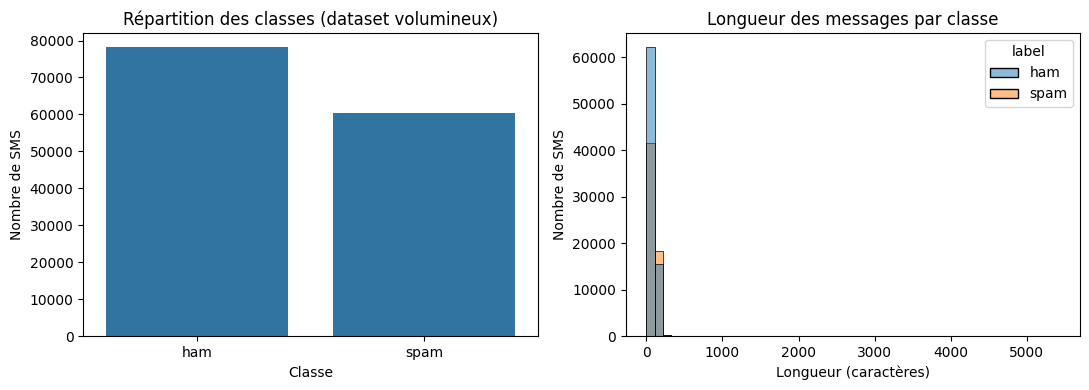

In [174]:
# Exploration rapide : équilibre des classes et longueur des messages
df_big["length"] = df_big["message_clean"].str.len()
print("Longueur des messages par classe :")
display(df_big.groupby("label")["length"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df_big, x="label", ax=axes[0])
axes[0].set_title("Répartition des classes (dataset volumineux)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de SMS")

sns.histplot(data=df_big, x="length", hue="label", bins=50, ax=axes[1])
axes[1].set_title("Longueur des messages par classe")
axes[1].set_xlabel("Longueur (caractères)")
axes[1].set_ylabel("Nombre de SMS")

plt.tight_layout()
plt.show()

## Découpage train / test

On découpe en train / test, comme pour le dataset précédent.

Mais nous faisons le choix ici de ne pas procéder à une augmentation des données.  
En effet, le dataset est presque équilibré (environ 44 % de spam), alors que le dataset précédent était très déséquilibré (13 % de spam) et nécessitait de fabriquer des spams artificiel pour équilibrer le dataset.

In [175]:
# Découpage stratifié (mêmes proportions ham / spam dans le train et le test)
Xb = df_big["message_clean"]
yb = df_big["label"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

print("Train :", len(Xb_train), "messages  |  Test :", len(Xb_test), "messages")
print("\nRépartition du train :")
print(yb_train.value_counts())

Train : 110812 messages  |  Test : 27704 messages

Répartition du train :
label
ham     62538
spam    48274
Name: count, dtype: int64


## Baseline machine learning (TF-IDF + ElasticNet)

On rejoue la baseline avec les mêmes réglages que sur l'autre dataset : TF-IDF (unigrammes + bigrammes) puis régression logistique ElasticNet. On mesure le temps d'entraînement pour la comparaison.

In [176]:
import time

# Mêmes réglages de vectorisation que pour l'UCI
vectorizer_big = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
Xb_train_vec = vectorizer_big.fit_transform(Xb_train)
Xb_test_vec  = vectorizer_big.transform(Xb_test)
print("Matrice train :", Xb_train_vec.shape, " | vocabulaire :", len(vectorizer_big.vocabulary_))

# Même modèle ElasticNet, on chronomètre l'entraînement
baseline_big = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    C=1.0,
    max_iter=2000,
    random_state=42,
)
debut = time.time()
baseline_big.fit(Xb_train_vec, yb_train)
temps_ml_big = time.time() - debut
print(f"Temps d'entraînement ElasticNet : {temps_ml_big:.1f} s")

yb_pred_bl = baseline_big.predict(Xb_test_vec)
print("\nRapport de classification (jeu de test)")
print(classification_report(yb_test, yb_pred_bl, digits=3))

Matrice train : (110812, 181952)  | vocabulaire : 181952
Temps d'entraînement ElasticNet : 128.9 s

Rapport de classification (jeu de test)
              precision    recall  f1-score   support

         ham      0.809     0.852     0.830     15635
        spam      0.795     0.739     0.766     12069

    accuracy                          0.803     27704
   macro avg      0.802     0.796     0.798     27704
weighted avg      0.803     0.803     0.802     27704



## Deep learning

On reprend la même architecture que dans la partie Deep Learning précédente: passage des messages en suites d'entiers, puis Embedding → LSTM → Layer Normalization → Dense (ReLU) → sortie sigmoïde.

Seule petite adaptation au volume et au caractère multilingue : on autorise un vocabulaire plus large (20 000 mots au lieu de 10 000), car le dataset contient beaucoup plus de mots différents.

In [177]:
# Passage du texte en suites d'entiers (vocabulaire appris sur le train uniquement)
num_mots_big = 20000   # vocabulaire plus large : dataset volumineux et multilingue
max_len_big  = 50      # meme longueur de sequence que pour l'UCI

vocab_big = construire_vocab(Xb_train.values, num_mots_big)
vocab_size_big = len(vocab_big) + 2  # + padding + OOV

Xb_train_seq = encoder_sequences(Xb_train.values, vocab_big, max_len_big)
Xb_test_seq  = encoder_sequences(Xb_test.values, vocab_big, max_len_big)

# Etiquettes en 0 / 1 (spam = 1)
yb_train_rnn = (yb_train == "spam").astype("int32").values
yb_test_rnn  = (yb_test == "spam").astype("int32").values

print("Forme train :", tuple(Xb_train_seq.shape), " | test :", tuple(Xb_test_seq.shape))
print("Taille du vocabulaire :", vocab_size_big)

Forme train : (110812, 50)  | test : (27704, 50)
Taille du vocabulaire : 20000


In [178]:
torch.manual_seed(42)  # reproductibilite

# Meme architecture (seul l'input_dim change avec le vocabulaire)
model_big = RNNSpam(taille_vocab=vocab_size_big)
print(model_big)
print(f"Nombre de parametres : {sum(p.numel() for p in model_big.parameters()):,}")

RNNSpam(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dense): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sortie): Linear(in_features=32, out_features=1, bias=True)
)
Nombre de parametres : 1,315,521


### Entraînement

On entraîne le RNN sur ce dataset 25 fois plus grand. En conséquence, on augmente la taille des lots (`batch_size`) pour limiter le temps d'entrainement.

In [179]:
debut = time.time()
historique_big = entrainer_rnn(
    model_big, Xb_train_seq, yb_train_rnn,
    epochs=5, batch_size=128, val_split=0.1,
)
temps_rnn_big = time.time() - debut
print(f"\nTemps d'entrainement du RNN : {temps_rnn_big:.1f} s")

Epoch 1/5  perte 0.5342  val_loss 0.4761  val_acc 0.760
Epoch 2/5  perte 0.4371  val_loss 0.4297  val_acc 0.787
Epoch 3/5  perte 0.3800  val_loss 0.4092  val_acc 0.803
Epoch 4/5  perte 0.3339  val_loss 0.4085  val_acc 0.804
Epoch 5/5  perte 0.2936  val_loss 0.4126  val_acc 0.813

Temps d'entrainement du RNN : 30.0 s


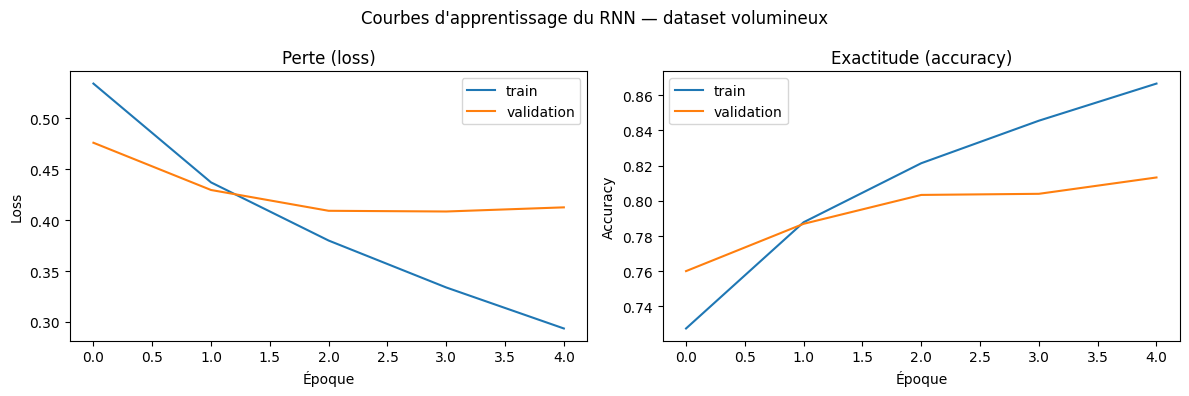

In [180]:
# Courbes d'apprentissage (perte et exactitude, train vs validation)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historique_big.history["loss"], label="train")
axes[0].plot(historique_big.history["val_loss"], label="validation")
axes[0].set_title("Perte (loss)")
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(historique_big.history["accuracy"], label="train")
axes[1].plot(historique_big.history["val_accuracy"], label="validation")
axes[1].set_title("Exactitude (accuracy)")
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.suptitle("Courbes d'apprentissage du RNN — dataset volumineux")
plt.tight_layout()
plt.show()

## Comparaison finale

On rassemble les quatre situations dans un seul tableau : les deux approches (ElasticNet et RNN) sur le petit dataset (résultats calculés plus haut, repris depuis le tableau `comparaison`) et sur le dataset volumineux. On compare la précision, le rappel et le F1 sur la classe spam, ainsi que le temps d'entraînement.

In [181]:
# --- Prédictions sur le test du dataset volumineux ---
proba_rnn_big  = predire(model_big, Xb_test_seq)
yb_pred_rnn    = (proba_rnn_big >= 0.5).astype(int)
yb_test_bin    = (yb_test == "spam").astype(int).values
yb_pred_bl_bin = (yb_pred_bl == "spam").astype(int)

# Lignes du dataset volumineux (mêmes colonnes que le tableau "comparaison" de l'UCI)
comparaison_big = pd.DataFrame(
    {
        "Précision (spam)": [precision_score(yb_test_bin, yb_pred_bl_bin),
                             precision_score(yb_test_bin, yb_pred_rnn)],
        "Rappel (spam)":    [recall_score(yb_test_bin, yb_pred_bl_bin),
                             recall_score(yb_test_bin, yb_pred_rnn)],
        "F1 (spam)":        [f1_score(yb_test_bin, yb_pred_bl_bin),
                             f1_score(yb_test_bin, yb_pred_rnn)],
        "Temps d'entraînement (s)": [temps_ml_big, temps_rnn_big],
    },
    index=["ElasticNet — grand dataset", "RNN (LSTM) — grand dataset"],
).round(3)

# On reprend les résultats du petit dataset (UCI), calculés dans la partie précédente
petit = comparaison.copy()
petit.index = ["ElasticNet — petit dataset (UCI)", "RNN (LSTM) — petit dataset (UCI)"]

tableau_final = pd.concat([petit, comparaison_big])
display(tableau_final)

,Précision (spam),Rappel (spam),F1 (spam),Temps d'entraînement (s)
ElasticNet — petit dataset (UCI),0.793,0.930,0.856,0.723
RNN (LSTM) — petit dataset (UCI),0.910,0.867,0.888,7.947
ElasticNet — grand dataset,0.795,0.739,0.766,128.869
RNN (LSTM) — grand dataset,0.826,0.719,0.769,29.999


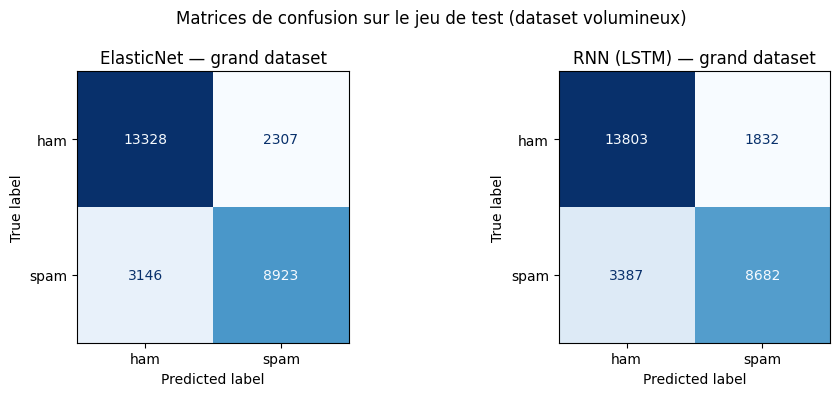

In [182]:
# Matrices de confusion sur le dataset volumineux
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(yb_test_bin, yb_pred_bl_bin), display_labels=["ham", "spam"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("ElasticNet — grand dataset")

ConfusionMatrixDisplay(
    confusion_matrix(yb_test_bin, yb_pred_rnn), display_labels=["ham", "spam"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("RNN (LSTM) — grand dataset")

plt.suptitle("Matrices de confusion sur le jeu de test (dataset volumineux)")
plt.tight_layout()
plt.show()

### Bilan

Le tableau ci-dessus devait montrer si l'avance prise par le RNN sur le petit dataset se confirme une fois confronté à beaucoup plus de données. Mais la réponse est nuancée : l'avance ne se creuse pas, elle se réduit.

Avec 25 fois plus de données et des classes équilibrées, le RNN obtient un F1 de 0.769 sur la classe spam, contre 0.766 pour ElasticNet : les deux modèles sont quasiment à égalité. Cependant, tous deux chutent nettement par rapport au petit dataset (0.888 et 0.856 sur l'UCI). Contrairement à ce qu'on aurait pu attendre, le volume n'a donc pas profité au RNN. L'explication la plus plausible ne tient pas à la quantité de données mais à leur nature : un dataset multilingue et bruité, bien plus difficile que ke petit dataset.

Concernant le temps de calcul. Sur le petit dataset, ElasticNet s'entraînait en moins d'une seconde quand le RNN demandait quelques secondes. Sur le grand dataset, le rapport s'inverse : le RNN ne prend que 30 s (sur GPU, grâce au passage à PyTorch), tandis qu'ElasticNet grimpe à 129 s — la vectorisation TF-IDF et la régression deviennent coûteuses à ce volume. L'avantage de rapidité s'est inversé, c'est désormais le RNN le plus rapide.

Limites de ce test :
- le dataset est multilingue et de provenance peu documentée : une part du bruit observé peut venir de la diversité des langues plutôt que des modèles eux-mêmes ;
- nous gardons une longueur de séquence et une architecture identiques à l'UCI pour une comparaison équitable, sans chercher à optimiser le RNN pour ce volume.

Conclusion. Ce second test visait à savoir si plus de volume renforcerait l'avance du RNN. Les chiffres ne le confirment pas : avec 25× plus de données, le RNN ne se détache pas de la baseline machine learning, et les deux modèles plafonnent ensemble autour de 0.77. Le facteur déterminant n'aura pas été le volume mais la qualité des données : un jeu propre et homogène (UCI) tire bien plus les deux modèles vers le haut qu'un grand dataset bruité. Reste une piste pour franchir ce plafond : importer une connaissance linguistique déjà acquise ailleurs via du transfer learning.

# Transfer learning via un Transformer multilingue pré-entraîné

Le bilan précédent a montré que, sur ce grand dataset bruité et multilingue, augmenter le volume ne suffit pas : le RNN ne creuse pas d'écart sur la baseline et les deux modèles plafonnent ensemble autour de 0.77. Notre conclusion était que le facteur limitant n'est pas la quantité mais la qualité des données.

Cette dernière partie teste une autre piste : plutôt qu'espérer apprendre la langue à partir de nos seules données, réutilisons un modèle qui la connaît déjà. C'est le principe du transfert learning.

Notre LSTM (Long Short-Term Memory) lit les messages mot à mot et doit tout réapprendre depuis zéro (vocabulaire, grammaire, sens) à partir du seul jeu d'entraînement. On utilise ici MiniLM multilingue (`Multilingual-MiniLM-L12-H384`), un modèle compact, pré-entraîné sur d'immenses corpus dans une centaine de langues.

Ce qu'on attend de ce test. Si le verrou était bien la diversité linguistique et le bruit des données, un modèle qui maîtrise déjà le multilingue devrait mieux y résister. On ne réentraîne pas tout depuis zéro : on l'ajuste (fine-tuning) à notre tâche spam / ham, ce qui est rapide et peu gourmand en données.

In [183]:
import time
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# La RTX 3070 est utilisée si CUDA est disponible ; sinon repli automatique sur le CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

Device : cuda
GPU    : NVIDIA GeForce RTX 3070 Laptop GPU


## Préparation : texte brut et tokenisation en sous-mots

Deux différences importantes avec les parties précédentes :

- **On n'applique pas `clean_text`.** Notre nettoyage (minuscules, suppression de la ponctuation et des chiffres) avait du sens pour TF-IDF et le RNN. Mais MiniLM a été pré-entraîné sur du texte *brut* : la casse, la ponctuation et les emojis portent une information qu'il sait exploiter. On lui fournit donc les messages d'origine.
- **On utilise le tokenizer du modèle**, pas notre propre vectorisation. Il découpe le texte en *sous-mots* (SentencePiece) : un mot inconnu est décomposé en fragments connus, ce qui limite le problème des mots hors vocabulaire — précieux sur un corpus multilingue. MiniLM réutilisant le vocabulaire de XLM-RoBERTa, on charge ce tokenizer-là.

On conserve le **même découpage train / test** (même `random_state`, mêmes proportions) que les autres modèles, pour une comparaison équitable.

In [184]:
# Même découpage que les autres modèles (mêmes lignes, même random_state),
# mais sur le texte BRUT : un Transformer pré-entraîné exploite la casse,
# la ponctuation et les emojis que clean_text supprimait.
Xtf_train, Xtf_test, ytf_train, ytf_test = train_test_split(
    df_big["message"], df_big["label"],
    test_size=0.2, random_state=42, stratify=df_big["label"],
)

# MiniLM multilingue : modèle compact (12 couches, hidden 384). Son dépôt ne fournit
# pas de tokenizer ; il réutilise le vocabulaire de XLM-RoBERTa, qu'on charge donc à part.
MODEL_NAME = "microsoft/Multilingual-MiniLM-L12-H384"
TOK_NAME   = "xlm-roberta-base"
MAX_LEN    = 64   # les SMS sont courts : 64 sous-mots couvrent la quasi-totalité

tokenizer = AutoTokenizer.from_pretrained(TOK_NAME)

def encoder(textes):
    # Le tokenizer produit input_ids (sous-mots SentencePiece) + attention_mask
    return tokenizer(
        list(textes),
        truncation=True, padding="max_length", max_length=MAX_LEN,
        return_tensors="pt",
    )

enc_train = encoder(Xtf_train)
enc_test  = encoder(Xtf_test)

# Étiquettes en entiers : spam = 1, ham = 0
ytf_train_bin = torch.tensor((ytf_train == "spam").astype(int).values)
ytf_test_bin  = torch.tensor((ytf_test  == "spam").astype(int).values)

print("Train :", len(Xtf_train), "| Test :", len(Xtf_test))
print("Exemple de tokenisation :", tokenizer.tokenize("Free entry! Win a prize 🎉")[:12])

Train : 110812 | Test : 27704
Exemple de tokenisation : ['▁Free', '▁entry', '!', '▁Win', '▁a', '▁pri', 'ze', '▁', '🎉']


## Fine-tuning

On charge MiniLM pré-entraîné en lui ajoutant une **tête de classification** à deux sorties (ham / spam), initialisée aléatoirement. L'entraînement ajuste l'ensemble sur notre tâche.

Quelques choix propres au fine-tuning et à l'exploitation du GPU :

- **Learning rate faible (3e-5)** : on ajuste finement des poids déjà pertinents, sans détruire ce que le pré-entraînement a appris.
- **Peu d'epochs (2)** : le gros du travail linguistique est déjà fait ; quelques passages suffisent, et au-delà le sur-apprentissage guette.
- **Précision mixte (fp16) + batch de 64** : la RTX 3070 possède des *Tensor Cores* que le calcul fp32 standard n'exploite pas. En passant en précision mixte, on accélère l'entraînement d'un facteur ~2 sans perte de qualité notable, tout en tenant large dans les 8 Go.

On chronomètre l'entraînement pour le comparer aux autres modèles — c'était le nerf de la guerre du bilan précédent.

In [185]:
torch.manual_seed(42)

modele_tf = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

train_ds = TensorDataset(enc_train["input_ids"], enc_train["attention_mask"], ytf_train_bin)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

optimiseur = torch.optim.AdamW(modele_tf.parameters(), lr=3e-5)

# Précision mixte (fp16) : exploite les Tensor Cores de la RTX 3070 (~2x plus rapide).
# Le GradScaler évite que les très petits gradients en fp16 ne soient arrondis à zéro.
use_amp = (device.type == "cuda")
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
EPOCHS  = 2

debut = time.time()
modele_tf.train()
for epoch in range(EPOCHS):
    perte_cumul = 0.0
    for i, (ids, mask, lab) in enumerate(train_dl):
        ids, mask, lab = ids.to(device), mask.to(device), lab.to(device)
        optimiseur.zero_grad()
        with torch.autocast("cuda", enabled=use_amp):
            sortie = modele_tf(input_ids=ids, attention_mask=mask, labels=lab)
        scaler.scale(sortie.loss).backward()
        scaler.step(optimiseur)
        scaler.update()
        perte_cumul += sortie.loss.item()
        if (i + 1) % 200 == 0:
            print(f"  epoch {epoch+1} - batch {i+1}/{len(train_dl)} - perte {sortie.loss.item():.4f}")
    print(f"Epoch {epoch+1}/{EPOCHS} - perte moyenne : {perte_cumul/len(train_dl):.4f}")

temps_tf_big = time.time() - debut
print(f"\nTemps d'entraînement Transformer : {temps_tf_big:.1f} s")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/Multilingual-MiniLM-L12-H384 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  epoch 1 - batch 200/1732 - perte 0.4442
  epoch 1 - batch 400/1732 - perte 0.3728
  epoch 1 - batch 600/1732 - perte 0.4540
  epoch 1 - batch 800/1732 - perte 0.4594
  epoch 1 - batch 1000/1732 - perte 0.4015
  epoch 1 - batch 1200/1732 - perte 0.3909
  epoch 1 - batch 1400/1732 - perte 0.3651
  epoch 1 - batch 1600/1732 - perte 0.3522
Epoch 1/2 - perte moyenne : 0.4403
  epoch 2 - batch 200/1732 - perte 0.3365
  epoch 2 - batch 400/1732 - perte 0.3835
  epoch 2 - batch 600/1732 - perte 0.3378
  epoch 2 - batch 800/1732 - perte 0.3946
  epoch 2 - batch 1000/1732 - perte 0.3458
  epoch 2 - batch 1200/1732 - perte 0.3483
  epoch 2 - batch 1400/1732 - perte 0.4036
  epoch 2 - batch 1600/1732 - perte 0.2503
Epoch 2/2 - perte moyenne : 0.3514

Temps d'entraînement Transformer : 322.8 s


## Évaluation

On prédit sur le **même jeu de test** que les autres modèles et on calcule les mêmes métriques (précision, rappel, score F1 sur la classe spam), puis on ajoute la ligne du Transformer au tableau comparatif final.

In [186]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

modele_tf.eval()
test_ds = TensorDataset(enc_test["input_ids"], enc_test["attention_mask"])
test_dl = DataLoader(test_ds, batch_size=128)

preds = []
with torch.no_grad():
    for ids, mask in test_dl:
        with torch.autocast("cuda", enabled=(device.type == "cuda")):
            logits = modele_tf(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
        preds.append(logits.argmax(dim=1).cpu())
ytf_pred = torch.cat(preds).numpy()
ytf_vrai = ytf_test_bin.numpy()

print(classification_report(ytf_vrai, ytf_pred, target_names=["ham", "spam"], digits=3))

# Ajout de la ligne Transformer au tableau comparatif final
ligne_tf = pd.DataFrame(
    {
        "Précision (spam)": [precision_score(ytf_vrai, ytf_pred)],
        "Rappel (spam)":    [recall_score(ytf_vrai, ytf_pred)],
        "F1 (spam)":        [f1_score(ytf_vrai, ytf_pred)],
        "Temps d'entraînement (s)": [temps_tf_big],
    },
    index=["MiniLM multilingue — grand dataset"],
).round(3)

tableau_final_tf = pd.concat([tableau_final, ligne_tf])
display(tableau_final_tf)

              precision    recall  f1-score   support

         ham      0.840     0.892     0.865     15635
        spam      0.848     0.779     0.812     12069

    accuracy                          0.843     27704
   macro avg      0.844     0.836     0.838     27704
weighted avg      0.843     0.843     0.842     27704



,Précision (spam),Rappel (spam),F1 (spam),Temps d'entraînement (s)
ElasticNet — petit dataset (UCI),0.793,0.930,0.856,0.723
RNN (LSTM) — petit dataset (UCI),0.910,0.867,0.888,7.947
ElasticNet — grand dataset,0.795,0.739,0.766,128.869
RNN (LSTM) — grand dataset,0.826,0.719,0.769,29.999
MiniLM multilingue — grand dataset,0.848,0.779,0.812,322.816


### Bilan

D'un point de vue des performances : Sur le grand dataset, MiniLM atteint un F1 de 0.812 sur la classe spam versus 0.769 pour le RNN et 0.766 pour ElasticNet. C'est le premier modèle à se détacher nettement (+0.043 sur le RNN, +0.046 sur la baseline). 

Cependant, il faut nuancer. MiniLM reste loin des scores obtenus sur le petit dataset UCI propre (0.888 pour le RNN, 0.856 pour ElasticNet). Autrement dit, le Transformer pré-entraîné encaisse mieux le bruit et le multilingue, mais ne franchit pas le plafond imposé par la qualité des données. Il compense une partie du bruit, il ne l'efface pas.

Concernant le temps de calcul : L'entraînement a pris 322.8 s, soit environ 2.5× le temps d'ElasticNet (129 s) et près de 10× celui du RNN (30 s) — et ce malgré deux optimisations : un modèle volontairement compact (MiniLM, ~21 M de paramètres ) qui exploite les Tensor Cores du GPU. Sans elles, le même entraînement aurait été bien plus lourd. Le gain de F1 a donc un coût bien réel : le meilleur modèle est aussi, de loin, le plus lent.

Limites de ce test :
- on n'a pas cherché à pousser le Transformer : 2 epochs, séquences de 64 tokens, aucun réglage fin des hyperparamètres — un modèle plus gros (XLM-RoBERTa, BERT multilingue) ou un entraînement plus long gagneraient sans doute quelques points, au prix d'un temps bien supérieur ;
- l'entraînement sur GPU n'est pas parfaitement déterministe : les chiffres peuvent varier d'une exécution à l'autre ;
- le dataset reste multilingue, bruité.

En conclusion, le grand dataset bruité renvoyait RNN et ElasticNet au même mur : ni l'un ni l'autre ne dépassait 0.77, prouvant que l'augmentation du volume des données avait atteint ses limites.
Ainsi, face à l'augmentation des données seul MiniLM s'en détache. 
Au final, d'un point de vue des performances, MiniLM (0.812) se classe devant RNN (0.769) et ElasticNet (0.766). Cependant, ils sont tous en dessous de ce qu'ils atteignaient sur le petit jeu de données. Pour le deep learning, plus de données ne vaut pas de meilleures données et quand la qualité ne peut plus progresser, le transfert learning se révèle la voie la plus payante.

# Export des modèles pour le dashboard

On sérialise le **trio entraîné sur le dataset multilingue** (`df_big`) — le seul jeu de données où coexistent les trois approches — afin que le dashboard puisse simplement *charger puis inférer*, sans ré-entraînement (le fine-tuning du Transformer serait bien trop long à relancer à chaque démarrage).

Les artefacts sont écrits dans `../artifacts/` (hors Git, au même titre que `../data/`). Il suffit de réexécuter la cellule ci-dessous pour les régénérer.

| Modèle | Fichiers | Entrée attendue |
|---|---|---|
| **ML** (TF-IDF + ElasticNet) | `ml_vectorizer.joblib` + `ml_baseline.joblib` | texte **nettoyé** (`clean_text`) |
| **RNN** (LSTM PyTorch) | `rnn_state.pt` + `rnn_vocab.json` + `rnn_config.json` | texte **nettoyé** (`clean_text`) |
| **Transformer** (MiniLM) | dossier `transformer/` (poids + tokenizer) | texte **brut** |

Le fichier `meta.json` récapitule les classes et le prétraitement attendu par chaque modèle, pour que le dashboard reste cohérent avec l'entraînement.

In [ ]:
# === Export des modèles entraînés pour le dashboard ===
# Trio multilingue (tous entraînés sur df_big) -> chargement + inférence sans ré-entraînement.
import json
import joblib
from pathlib import Path

ART = Path("..") / "artifacts"          # notebooks/ -> ../artifacts (hors Git, comme ../data)
ART.mkdir(parents=True, exist_ok=True)
(ART / "transformer").mkdir(exist_ok=True)

# --- 1. Machine learning : TF-IDF + régression logistique ElasticNet ---
joblib.dump(vectorizer_big, ART / "ml_vectorizer.joblib")
joblib.dump(baseline_big,   ART / "ml_baseline.joblib")

# --- 2. RNN PyTorch : poids + vocabulaire + configuration de reconstruction ---
torch.save(model_big.state_dict(), ART / "rnn_state.pt")
(ART / "rnn_vocab.json").write_text(json.dumps(vocab_big, ensure_ascii=False), encoding="utf-8")
(ART / "rnn_config.json").write_text(json.dumps({
    "vocab_size": vocab_size_big,   # taille passée au constructeur RNNSpam
    "max_len":    max_len_big,       # longueur de séquence (padding / troncature)
    "dim_embedding": 64,             # valeurs par défaut de RNNSpam (model_big = RNNSpam(...))
    "dim_lstm":      64,
    "pad": PAD,
    "oov": OOV,
}, ensure_ascii=False, indent=2), encoding="utf-8")

# --- 3. Transformer MiniLM multilingue fine-tuné : poids + tokenizer ---
modele_tf.save_pretrained(ART / "transformer")
tokenizer.save_pretrained(ART / "transformer")
(ART / "transformer_config.json").write_text(json.dumps({
    "max_len": MAX_LEN,
    "labels": {"0": "ham", "1": "spam"},
}, ensure_ascii=False, indent=2), encoding="utf-8")

# --- Métadonnées communes : classes + prétraitement attendu par modèle ---
(ART / "meta.json").write_text(json.dumps({
    "dataset": "sms_scam_multilingue",
    "classes": ["ham", "spam"],     # index 0 = ham, index 1 = spam
    "preprocessing": {
        "ml": "clean_text",
        "rnn": "clean_text",
        "transformer": "raw",
    },
}, ensure_ascii=False, indent=2), encoding="utf-8")

print("Modèles exportés dans :", ART.resolve())
for p in sorted(ART.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ART).as_posix():<32} {p.stat().st_size/1024:8.0f} Ko")

## Métriques de test pour l'onglet « Métriques » du dashboard

On exporte, pour le jeu de test de `df_big`, la **probabilité de spam** prédite par chacun des trois modèles ainsi que la vérité terrain. Le dashboard recalcule alors instantanément le tableau des scores, les matrices de confusion et les courbes ROC — sans avoir besoin des données, et en réagissant au seuil choisi dans l'interface.

In [ ]:
# === Export des métriques de test pour l'onglet "Métriques" du dashboard ===
# Pour le jeu de test de df_big, on sérialise la probabilité de spam des trois modèles
# + la vérité terrain. Le dashboard recalcule scores, matrices de confusion et ROC
# sans les données (rapide, et réactif au seuil choisi dans l'interface).
import json
import numpy as np
import torch
from pathlib import Path

ART = Path("..") / "artifacts"
ART.mkdir(parents=True, exist_ok=True)

# Vérité terrain (spam = 1). Les trois modèles partagent le MÊME découpage
# (même random_state, même stratify, mêmes lignes) -> un seul y_true, même ordre.
y_true = (yb_test == "spam").astype(int).values

# --- ML : probabilité de spam ---
spam_idx_big = list(baseline_big.classes_).index("spam")
proba_ml = baseline_big.predict_proba(Xb_test_vec)[:, spam_idx_big]

# --- RNN : probabilité de spam ---
proba_rnn = predire(model_big, Xb_test_seq)

# --- Transformer : probabilité de spam (softmax sur la classe 1) ---
modele_tf.eval()
loader_tf = DataLoader(TensorDataset(enc_test["input_ids"], enc_test["attention_mask"]), batch_size=128)
morceaux = []
with torch.no_grad():
    for ids, mask in loader_tf:
        with torch.autocast("cuda", enabled=(device.type == "cuda")):
            logits = modele_tf(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
        morceaux.append(torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
proba_tf = np.concatenate(morceaux)

# Arrondi à 5 décimales : fidélité suffisante pour la ROC, fichier plus léger.
metrics = {
    "n_test": int(len(y_true)),
    "positive_rate": float(y_true.mean()),
    "classes": ["ham", "spam"],
    "y_true": y_true.tolist(),
    "models": {
        "ml":          {"proba": [round(float(p), 5) for p in proba_ml]},
        "rnn":         {"proba": [round(float(p), 5) for p in proba_rnn]},
        "transformer": {"proba": [round(float(p), 5) for p in proba_tf]},
    },
}
(ART / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False), encoding="utf-8")
print(f"metrics.json écrit : {len(y_true):,} messages de test, "
      f"{(ART / 'metrics.json').stat().st_size/1024:.0f} Ko")